# Notebook 1 — Data Cleaning & Preparation
**Project:** E-commerce Customer Segmentation & Revenue Risk Scoring  
**Dataset:** UCI Online Retail II (2009–2011)  
**Author:** Pratiksha Dandriyal

---

## Objective
Combine both year sheets, remove unusable records, engineer base columns, and save a clean dataset for EDA and RFM analysis.

## Steps
1. Load & combine both sheets
2. Understand raw data quality
3. Remove cancellations
4. Drop rows with missing Customer ID
5. Remove invalid Quantity & Price rows
6. Engineer new columns
7. Summarise cleaning impact
8. Save clean data

---
## 1. Imports & settings

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chart style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = {'keep': '#1D9E75', 'drop': '#D85A30', 'cancel': '#7F77DD'}

FILE_PATH  = r'C:\Users\prati_t686nlu\OneDrive\Desktop\online_retail_II.xlsx'
OUTPUT_DIR = r'C:\Users\prati_t686nlu\OneDrive\Desktop'

---
## 2. Load & combine both sheets

In [15]:
df1 = pd.read_excel(FILE_PATH, sheet_name='Year 2009-2010')
df2 = pd.read_excel(FILE_PATH, sheet_name='Year 2010-2011')

df = pd.concat([df1, df2], ignore_index=True)

print(f'Sheet 1 (2009-2010): {df1.shape[0]:,} rows')
print(f'Sheet 2 (2010-2011): {df2.shape[0]:,} rows')
print(f'Combined            : {df.shape[0]:,} rows')
print(f'Columns             : {list(df.columns)}')

Sheet 1 (2009-2010): 525,461 rows
Sheet 2 (2010-2011): 541,910 rows
Combined            : 1,067,371 rows
Columns             : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


---
## 3. Raw data quality check

In [3]:
print('=== Data types ===')
print(df.dtypes)
print()
print('=== Null values ===')
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
print(pd.DataFrame({'null_count': nulls, 'null_%': null_pct}))
print()
print('=== Sample rows ===')
df.head(5)

=== Data types ===
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

=== Null values ===
             null_count  null_%
Invoice               0    0.00
StockCode             0    0.00
Description        4382    0.41
Quantity              0    0.00
InvoiceDate           0    0.00
Price                 0    0.00
Customer ID      243007   22.77
Country               0    0.00

=== Sample rows ===


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
print('=== Quantity & Price range ===')
print(df[['Quantity', 'Price']].describe().round(2))

neg_qty   = (df['Quantity'] < 0).sum()
neg_price = (df['Price'] < 0).sum()
zero_price = (df['Price'] == 0).sum()
print(f'\nNegative Quantity rows : {neg_qty:,}')
print(f'Negative Price rows    : {neg_price:,}')
print(f'Zero Price rows        : {zero_price:,}')

=== Quantity & Price range ===
         Quantity       Price
count  1067371.00  1067371.00
mean         9.94        4.65
std        172.71      123.55
min     -80995.00   -53594.36
25%          1.00        1.25
50%          3.00        2.10
75%         10.00        4.15
max      80995.00    38970.00

Negative Quantity rows : 22,950
Negative Price rows    : 5
Zero Price rows        : 6,202


---
## 4. Step-by-step cleaning

In [5]:
raw_count = len(df)
cleaning_log = [{'step': 'Raw data', 'rows': raw_count, 'dropped': 0}]

# --- Step 1: Separate cancellations ---
is_cancel  = df['Invoice'].astype(str).str.startswith('C')
df_cancels = df[is_cancel].copy()
df         = df[~is_cancel].copy()

cleaning_log.append({'step': 'Remove cancellations', 'rows': len(df), 'dropped': raw_count - len(df)})
print(f'Cancellation rows removed : {len(df_cancels):,} ({len(df_cancels)/raw_count*100:.2f}%)')
print(f'Rows remaining            : {len(df):,}')

Cancellation rows removed : 19,494 (1.83%)
Rows remaining            : 1,047,877


In [6]:
# --- Step 2: Drop missing Customer ID ---
before = len(df)
df     = df[df['Customer ID'].notnull()].copy()

cleaning_log.append({'step': 'Drop null Customer ID', 'rows': len(df), 'dropped': before - len(df)})
print(f'Null Customer ID rows removed : {before - len(df):,} ({(before - len(df))/raw_count*100:.2f}% of raw)')
print(f'Rows remaining                : {len(df):,}')

Null Customer ID rows removed : 242,257 (22.70% of raw)
Rows remaining                : 805,620


In [7]:
# --- Step 3: Remove invalid Quantity & Price ---
before = len(df)
df     = df[(df['Quantity'] > 0) & (df['Price'] > 0)].copy()

cleaning_log.append({'step': 'Remove invalid Qty/Price', 'rows': len(df), 'dropped': before - len(df)})
print(f'Invalid Qty/Price rows removed : {before - len(df):,}')
print(f'Rows remaining                 : {len(df):,}')

Invalid Qty/Price rows removed : 71
Rows remaining                 : 805,549


---
## 5. Feature engineering

In [8]:
df['TotalRevenue'] = df['Quantity'] * df['Price']

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year']        = df['InvoiceDate'].dt.year
df['Month']       = df['InvoiceDate'].dt.month
df['YearMonth']   = df['InvoiceDate'].dt.to_period('M')
df['DayOfWeek']   = df['InvoiceDate'].dt.day_name()

df['Customer ID'] = df['Customer ID'].astype(int)

print('New columns added: TotalRevenue, Year, Month, YearMonth, DayOfWeek')
print(f'Final shape: {df.shape}')
df.head(3)

New columns added: TotalRevenue, Year, Month, YearMonth, DayOfWeek
Final shape: (805549, 13)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalRevenue,Year,Month,YearMonth,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,2009-12,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,2009-12,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,2009-12,Tuesday


---
## 6. Cleaning summary stats

In [9]:
clean_count = len(df)
print('='*45)
print('         CLEANING SUMMARY')
print('='*45)
print(f'Raw rows              : {raw_count:>10,}')
print(f'Clean rows            : {clean_count:>10,}')
print(f'Rows removed          : {raw_count - clean_count:>10,}  ({(raw_count - clean_count)/raw_count*100:.1f}%)')
print(f'Rows retained         : {clean_count/raw_count*100:>9.1f}%')
print(f'Unique customers      : {df["Customer ID"].nunique():>10,}')
print(f'Unique products       : {df["StockCode"].nunique():>10,}')
print(f'Total revenue         : \u00a3{df["TotalRevenue"].sum():>10,.0f}')
print(f'Date range            : {df["InvoiceDate"].min().date()} \u2192 {df["InvoiceDate"].max().date()}')
print('='*45)

         CLEANING SUMMARY
Raw rows              :  1,067,371
Clean rows            :    805,549
Rows removed          :    261,822  (24.5%)
Rows retained         :      75.5%
Unique customers      :      5,878
Unique products       :      4,631
Total revenue         : £17,743,429
Date range            : 2009-12-01 → 2011-12-09


---
## 7. Visualisation — cleaning impact

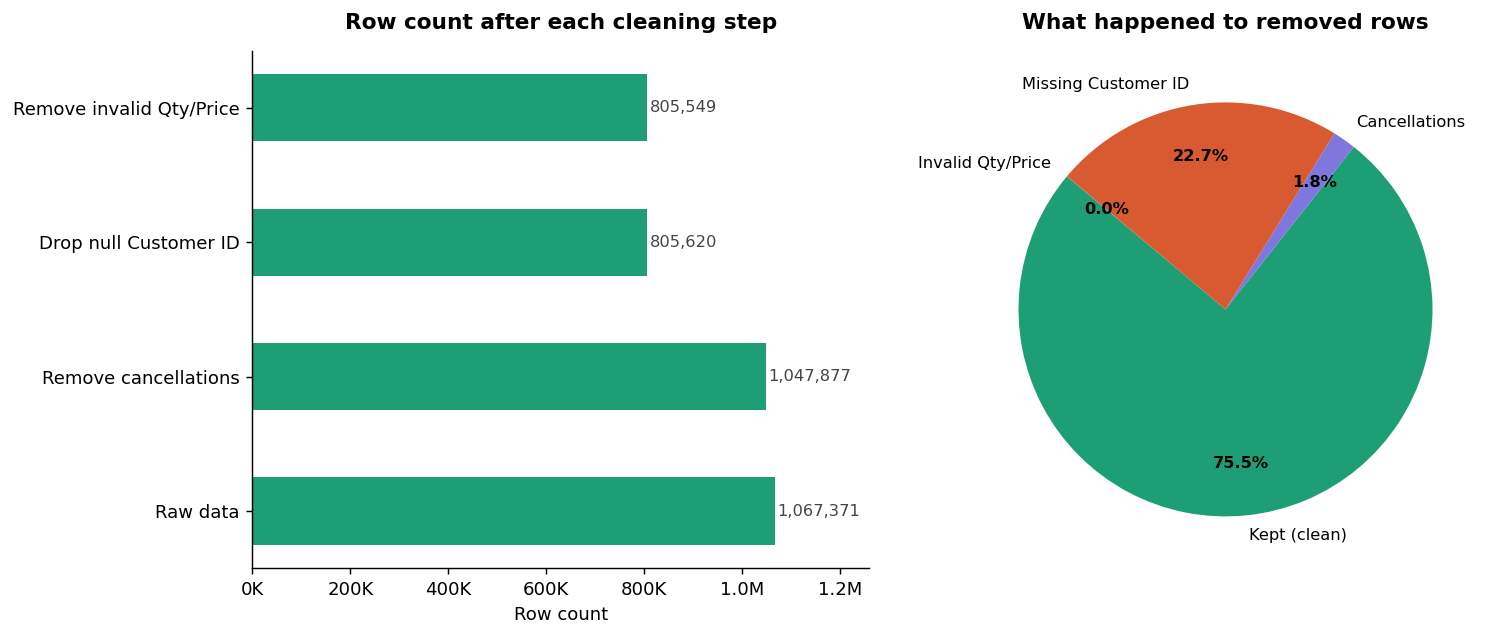

Chart saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Row count at each cleaning step
ax1     = axes[0]
log_df  = pd.DataFrame(cleaning_log)
bars    = ax1.barh(log_df['step'], log_df['rows'], color=PALETTE['keep'], height=0.5)
ax1.set_xlabel('Row count')
ax1.set_title('Row count after each cleaning step', fontsize=12, fontweight='bold', pad=12)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
for bar, row in zip(bars, log_df['rows']):
    ax1.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
             f'{row:,}', va='center', fontsize=9, color='#444')
ax1.set_xlim(0, log_df['rows'].max() * 1.18)

# Chart 2: What happened to removed rows
ax2    = axes[1]
labels = ['Kept (clean)', 'Cancellations', 'Missing Customer ID', 'Invalid Qty/Price']
sizes  = [
    clean_count,
    len(df_cancels),
    cleaning_log[2]['dropped'],
    cleaning_log[3]['dropped']
]
colors = [PALETTE['keep'], PALETTE['cancel'], PALETTE['drop'], '#FAC775']
wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.75, textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('What happened to removed rows', fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + r'\01_cleaning_summary.png', bbox_inches='tight')
plt.show()
print('Chart saved!')

---
## 8. Save clean data

In [11]:
df.to_csv(OUTPUT_DIR + r'\clean_retail.csv', index=False)
print('Saved: clean_retail.csv to Desktop')
print(f'Final shape: {df.shape}')
df.dtypes

Saved: clean_retail.csv to Desktop
Final shape: (805549, 13)


Invoice                 object
StockCode               object
Description             object
Quantity                 int64
InvoiceDate     datetime64[ns]
Price                  float64
Customer ID              int64
Country                 object
TotalRevenue           float64
Year                     int32
Month                    int32
YearMonth            period[M]
DayOfWeek               object
dtype: object

---
## Notebook summary

| Metric | Value |
|---|---|
| Raw rows | 1,067,371 |
| Cancellations removed | 19,494 (1.83%) |
| Missing Customer ID removed | ~243,000 (22.77%) |
| Invalid Qty/Price removed | small residual |
| **Clean rows retained** | **805,549 (75.5%)** |
| Unique customers | 5,878 |
| Total revenue | £17,743,429 |
| Date range | Dec 2009 → Dec 2011 |

**Next:** `02_eda.ipynb` — exploratory analysis on the clean dataset.